# Travel Insurance Claim Prediction

Trains and compares three classifiers (Decision Tree, Logistic Regression, Neural Network) to predict whether a travel insurance policy results in a claim. The target is heavily imbalanced (~1.5% "Yes"), so class-weighting and AUC/recall are used alongside accuracy throughout.

In [16]:
# Import Libraries 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, accuracy_score, precision_score, recall_score, roc_auc_score
)

sns.set(style="whitegrid")

## 1. Load data

In [17]:
df = pd.read_csv("/kaggle/input/datasets/samia231006/travel-insurance/travel insurance.csv")
print("Original shape:", df.shape)                        # rows/columns before cleaning
print("Missing values per column:\n", df.isna().sum())    # only Gender has nulls

Original shape: (63326, 11)
Missing values per column:
 Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64


## 2. Data cleaning (domain-specific anomalies)

In [18]:
# Negative Duration (5 rows) is impossible for a travel length -> drop.
df = df[df['Duration'] >= 0]

# Age == 118 (984 rows) is a placeholder/default value, not a real age
# (it forms an isolated spike far outside the natural age distribution).
df = df[df['Age'] <= 100]

# Negative Net Sales reflects real cancellations/refunds rather than bad
# data, so instead of dropping these rows we keep the info as its own
# binary flag, which the models can use as a signal.
df['Is_Refund'] = (df['Net Sales'] < 0).astype(int)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (62342, 12)


## 3. Gender + target

In [19]:
# Gender is missing on ~71% of rows -> drop the column (keeps all rows),
# rather than dropping every row that's missing it.
df = df.drop(columns=['Gender'])

# Encode the target as binary: 1 = claim made, 0 = no claim.
df['Claim'] = df['Claim'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Claim'])
y = df['Claim']

numeric_cols = ['Duration', 'Net Sales', 'Commision (in value)', 'Age', 'Is_Refund']
categorical_cols = ['Agency', 'Agency Type', 'Distribution Channel',
                     'Product Name', 'Destination']

## 4. Train / test split (before any encoding or scaling)

In [20]:
# Splitting first, then fitting the encoder/scaler only on the training
# set, avoids any information about the test set's categories or scale
# leaking into preprocessing -- and mirrors how a real production
# pipeline would handle genuinely unseen categories at inference time.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Numeric features get scaled; one-hot columns are left as 0/1 (scaling
# them is unnecessary and only reduces interpretability). Unseen
# categories at test/inference time are safely ignored rather than
# breaking the pipeline.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape, " X_test shape:", X_test_processed.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

X_train shape: (43639, 184)  X_test shape: (18703, 184)
Train class balance:
 Claim
0    0.985288
1    0.014712
Name: proportion, dtype: float64
Test class balance:
 Claim
0    0.985296
1    0.014704
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 5. EDA plots

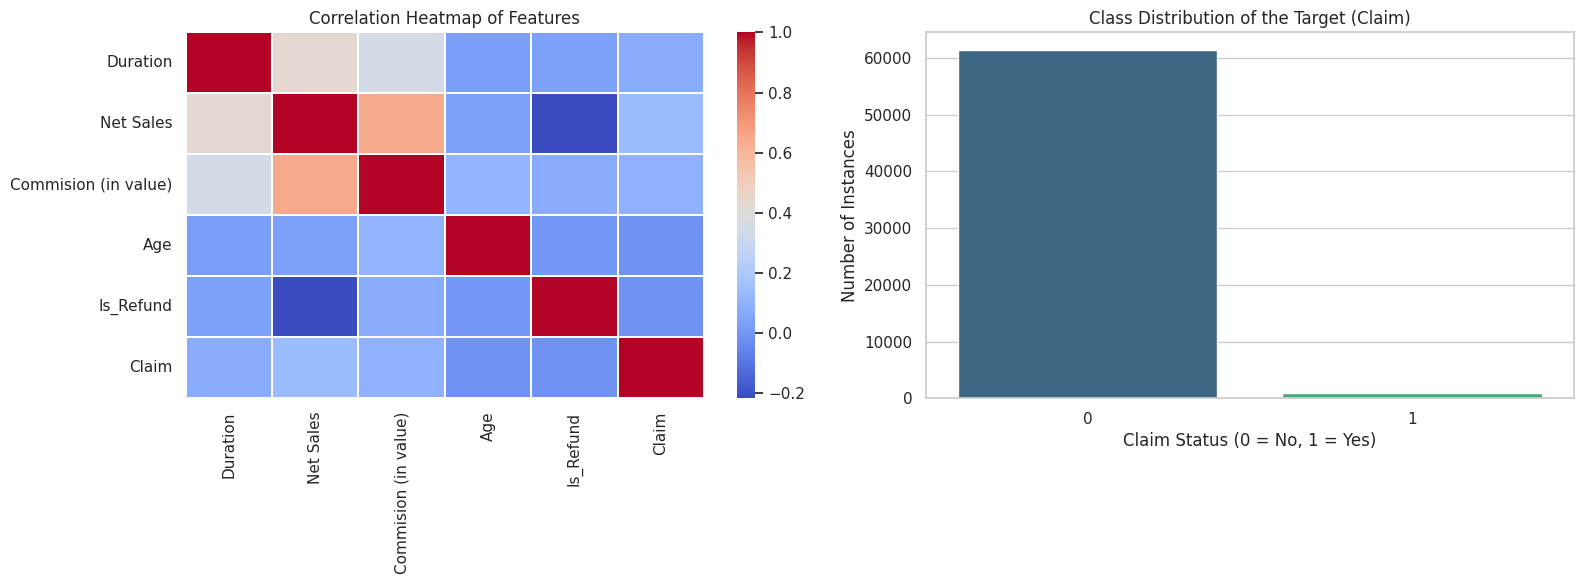

In [21]:
# Correlation heatmap (linear relationships between numeric features) and
# class distribution (how imbalanced the target is) shown side by side.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df[numeric_cols + ['Claim']].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.2, ax=axes[0])
axes[0].set_title("Correlation Heatmap of Features")

sns.countplot(data=df, x='Claim', hue='Claim', palette='viridis',
              legend=False, ax=axes[1])
axes[1].set_title("Class Distribution of the Target (Claim)")
axes[1].set_xlabel("Claim Status (0 = No, 1 = Yes)")
axes[1].set_ylabel("Number of Instances")

plt.tight_layout()
plt.show()

## 6. Decision Tree

In [22]:
# class_weight='balanced' upweights the rare "Yes" class during training.
# max_depth / min_samples_leaf constrain the tree so it can't memorize
# individual training rows (an unconstrained tree overfits severely here --
# depth 44 / 2,362 leaves / 99.8% train accuracy vs 97.0% test accuracy).
dt_model = DecisionTreeClassifier(
    class_weight='balanced', random_state=42,
    max_depth=10, min_samples_leaf=20
)
dt_model.fit(X_train_processed, y_train)

y_dt_pred = dt_model.predict(X_test_processed)
y_dt_probs = dt_model.predict_proba(X_test_processed)[:, 1]

print("=== Decision Tree ===")
print("Train accuracy:", dt_model.score(X_train_processed, y_train))
print(classification_report(y_test, y_dt_pred))
dt_accuracy = accuracy_score(y_test, y_dt_pred)
print(f"Test accuracy: {dt_accuracy:.4f}")

# AUC measures ranking quality independent of the 0.5 threshold, which
# matters here since accuracy alone is misleading on imbalanced data.
dt_fpr, dt_tpr, _ = roc_curve(y_test, y_dt_probs)
dt_auc = auc(dt_fpr, dt_tpr)
print(f"AUC: {dt_auc:.4f}")

=== Decision Tree ===
Train accuracy: 0.7237791883407044
              precision    recall  f1-score   support

           0       0.99      0.72      0.83     18428
           1       0.04      0.71      0.07       275

    accuracy                           0.72     18703
   macro avg       0.52      0.71      0.45     18703
weighted avg       0.98      0.72      0.82     18703

Test accuracy: 0.7151
AUC: 0.7350


## 7. Logistic Regression

In [23]:
# Same class_weight='balanced' treatment as the tree, so both models are
# compared on equal footing.
log_model = LogisticRegression(max_iter=5000, class_weight='balanced')
log_model.fit(X_train_processed, y_train)

y_log_pred = log_model.predict(X_test_processed)
y_log_probs = log_model.predict_proba(X_test_processed)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_log_pred))
log_accuracy = accuracy_score(y_test, y_log_pred)
print(f"Accuracy: {log_accuracy:.4f}")

log_fpr, log_tpr, _ = roc_curve(y_test, y_log_probs)
log_auc = auc(log_fpr, log_tpr)
print(f"AUC: {log_auc:.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.80      0.89     18428
           1       0.05      0.71      0.09       275

    accuracy                           0.80     18703
   macro avg       0.52      0.75      0.49     18703
weighted avg       0.98      0.80      0.87     18703

Accuracy: 0.7981
AUC: 0.8181


## 8. Neural Network (Keras)

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

# Class weights (Keras equivalent of sklearn's class_weight='balanced')
# so the network gets the same imbalance treatment as the other two models.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight = {0: len(y_train) / (2 * n_neg), 1: len(y_train) / (2 * n_pos)}
print("Class weights used for the Neural Network:", class_weight)

# Simple 3-hidden-layer feedforward network for binary classification.
model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# More epochs with early stopping on validation AUC, so training runs as
# long as it's actually helping rather than a fixed, possibly-too-short count.
early_stop = EarlyStopping(
    monitor='val_auc', mode='max', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train_processed, y_train,
    epochs=50, batch_size=32, validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0
)
print(f"Stopped after {len(history.history['loss'])} epochs (best restored on val_auc).")

# Predicted probabilities thresholded at 0.5 to get hard class labels.
y_pred_probs = model.predict(X_test_processed, verbose=0).ravel()
y_pred_mlp = (y_pred_probs > 0.5).astype(int)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_auc = roc_auc_score(y_test, y_pred_probs)

print("\n=== Neural Network ===")
print(classification_report(y_test, y_pred_mlp, zero_division=0))
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"AUC: {mlp_auc:.4f}")

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_probs)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

Class weights used for the Neural Network: {0: np.float64(0.5074656371374747), 1: np.float64(33.98676012461059)}
Stopped after 10 epochs (best restored on val_auc).

=== Neural Network ===
              precision    recall  f1-score   support

           0       1.00      0.71      0.83     18428
           1       0.04      0.79      0.07       275

    accuracy                           0.71     18703
   macro avg       0.52      0.75      0.45     18703
weighted avg       0.98      0.71      0.81     18703

Accuracy: 0.7063
AUC: 0.8196



=== Neural Network ===
              precision    recall  f1-score   support

           0       0.99      0.78      0.87     18428
           1       0.05      0.74      0.09       275

    accuracy                           0.78     18703
   macro avg       0.52      0.76      0.48     18703
weighted avg       0.98      0.78      0.86     18703

Accuracy: 0.7757
AUC: 0.8239


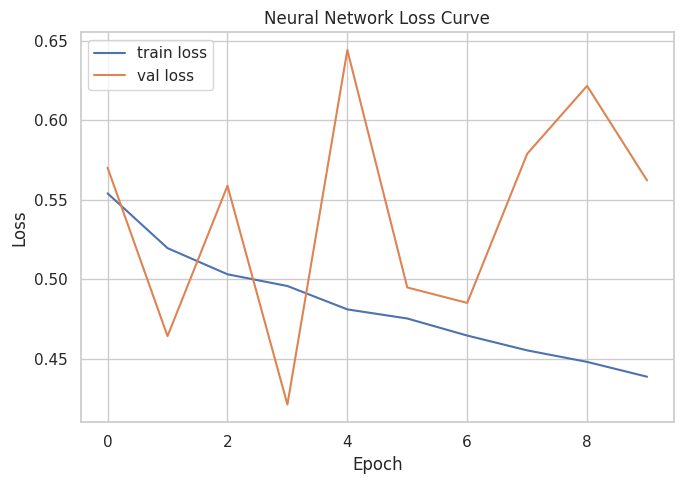

In [25]:
# Loss curve: sanity-check that the network is learning, not diverging,
# and that early stopping kicked in at a sensible point.
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Neural Network Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Confusion matrices — side by side for direct comparison

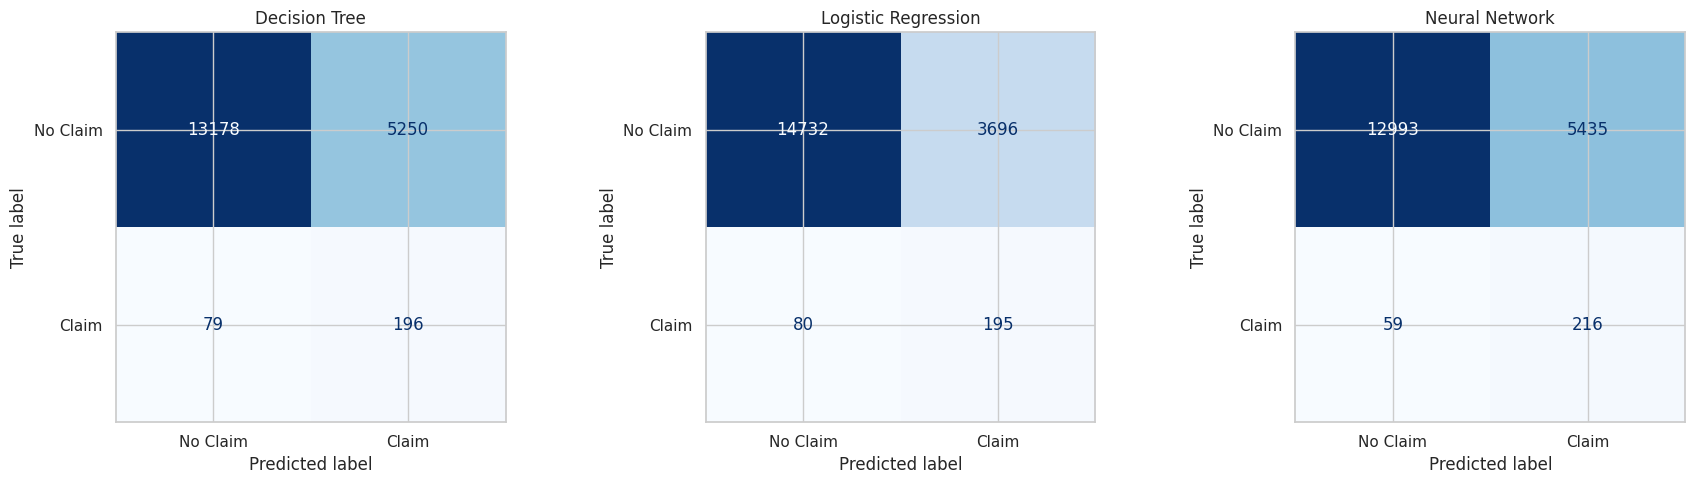

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name in [
    (axes[0], y_dt_pred, "Decision Tree"),
    (axes[1], y_log_pred, "Logistic Regression"),
    (axes[2], y_pred_mlp, "Neural Network"),
]:
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['No Claim', 'Claim']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 10. Model comparison — ROC curves + accuracy bar chart

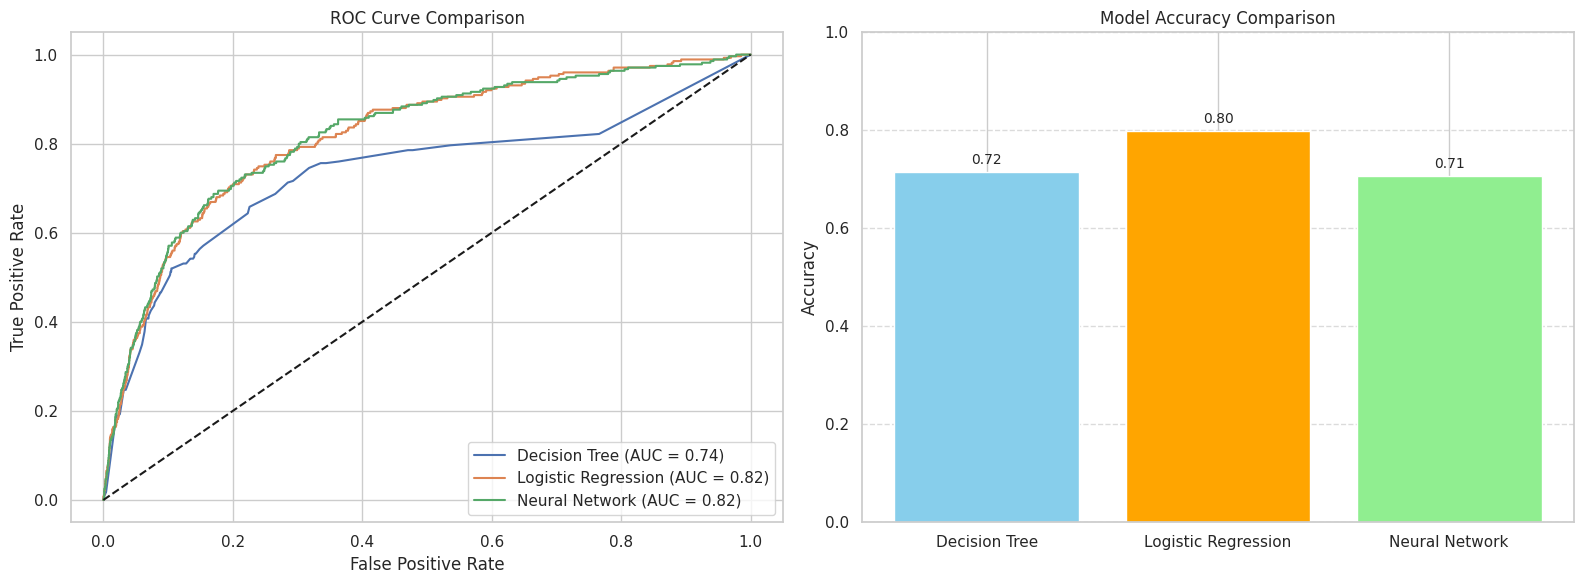

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overlaying all three ROC curves makes ranking quality (AUC) easy to compare.
axes[0].plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
axes[0].plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
axes[0].plot(fpr_mlp, tpr_mlp, label=f'Neural Network (AUC = {roc_auc_mlp:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Accuracy alone is misleading under class imbalance -- shown for reference
# only; AUC and recall above tell the fuller story.
models = ['Decision Tree', 'Logistic Regression', 'Neural Network']
accuracies = [dt_accuracy, log_accuracy, mlp_accuracy]
bars = axes[1].bar(models, accuracies, color=['skyblue', 'orange', 'lightgreen'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy Comparison')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                  f'{acc:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Summary

In [28]:
print("=== Summary ===")
print(f"Decision Tree       - Accuracy: {dt_accuracy:.4f}, AUC: {dt_auc:.4f}")
print(f"Logistic Regression - Accuracy: {log_accuracy:.4f}, AUC: {log_auc:.4f}")
print(f"Neural Network       - Accuracy: {mlp_accuracy:.4f}, AUC: {mlp_auc:.4f}")

=== Summary ===
Decision Tree       - Accuracy: 0.7151, AUC: 0.7350
Logistic Regression - Accuracy: 0.7981, AUC: 0.8181
Neural Network       - Accuracy: 0.7063, AUC: 0.8196
